In [1]:
import sys
from pathlib import Path

project_root = Path(r"c:\Users\floki\PycharmProjects\dash-azure-prototype")
src_root = project_root / "src"
for p in (project_root, src_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

artifact_root = project_root / "ml" / "models" / "artifacts"

In [2]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from itertools import combinations

from worker.models import ModelRepository
from worker.opt.algorithm import ModelInversionAlgorithm
from ml.scripts.plotting import plot_pareto_front

In [3]:
repo = ModelRepository(root=artifact_root, served_artifacts={"demo_lin"}, device="cpu")
model = repo.get("demo_lin")

print("Targets:", model.spec.targets)
print("Features:", model.spec.features)

target_bounds = {k: repo.bounds.get(k) for k in model.spec.targets[:4]}
target_bounds

Targets: ['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Y10']
Features: ['X1', 'X2', 'X3', 'X4', 'X6', 'X7', 'X8', 'X9']


{'Y1': (99.08313190162738, 100.68656237437848),
 'Y2': (48.21525565488826, 65.6279883095144),
 'Y3': (0.164, 0.542),
 'Y4': (78.0, 268.0)}

In [4]:
rng = np.random.default_rng(7)

def sample_targets(bounds_map):
    sampled = {}
    for key, bounds in bounds_map.items():
        if bounds is None:
            low, high = 0.0, 1.0
        else:
            low, high = bounds
        if low > high:
            low, high = high, low
        sampled[key] = float(rng.uniform(low, high))
    return sampled

objectives = sample_targets(target_bounds)
objectives

{'Y1': 100.08542902115987,
 'Y2': 63.83819970521242,
 'Y3': 0.4572091909126832,
 'Y4': 120.78936609821245}

In [5]:
algo = ModelInversionAlgorithm(
    repo=repo,
    objectives=objectives,
    runs=20000,
    population=100,
)

def safe_mape(pred, target):
    denom = abs(target) if target != 0 else 1.0
    return abs(pred - target) / denom

target_keys = list(objectives.keys())
x_key = target_keys[0]
y_key = target_keys[1] if len(target_keys) > 1 else target_keys[0]
pareto_y1 = []
pareto_y2 = []
pareto_results = []

pbar = tqdm(range(algo.generations), desc="Optimizing")
for _ in pbar:
    algo.step_once()
    results = algo.get_results()
    if results:
        best = results[0]
        mean_mape = float(
            np.mean([safe_mape(best.objectives[k], objectives[k]) for k in best.objectives])
        )
        pbar.set_postfix({"mean_mape": f"{mean_mape:.3f}"})
        pareto_y1.append([r.objectives[x_key] for r in results])
        pareto_y2.append([r.objectives[y_key] for r in results])
        pareto_results.append(results)

results = algo.get_results()
len(results)

Optimizing:   0%|          | 0/200 [00:00<?, ?it/s]

100

In [6]:
top = results[:5]

def safe_mape(pred, target):
    denom = abs(target) if target != 0 else 1.0
    return abs(pred - target) / denom

pd.DataFrame(
    [
        {
            "loss": r.loss,
            **{f"target_{k}": objectives[k] for k in r.objectives.keys()},
            **{f"pred_{k}": v for k, v in r.objectives.items()},
            **{
                f"mape_{k}": safe_mape(r.objectives[k], objectives[k])
                for k in r.objectives.keys()
            },
            **{f"x_{k}": v for k, v in r.x.items()},
        }
        for r in top
    ]
)

,loss,target_Y1,target_Y2,target_Y3,target_Y4,pred_Y1,pred_Y2,pred_Y3,pred_Y4,mape_Y1,...,mape_Y3,mape_Y4,x_X1,x_X2,x_X3,x_X4,x_X6,x_X7,x_X8,x_X9
0,0.162365,100.085429,63.8382,0.457209,120.789366,99.609267,57.974951,0.522671,70.699286,0.004758,...,0.143176,0.414689,0.514901,0.020700,0.141894,0.097277,0.062246,0.114342,0.031568,0.005987
1,0.193962,100.085429,63.8382,0.457209,120.789366,100.632797,64.174247,0.327820,181.335929,0.005469,...,0.282997,0.501257,0.513646,0.016021,0.148759,0.092942,0.078061,0.122509,0.024963,0.004096
2,0.200701,100.085429,63.8382,0.457209,120.789366,99.445465,57.801141,0.502171,96.759569,0.006394,...,0.098339,0.198940,0.515352,0.014331,0.141097,0.098008,0.062367,0.118241,0.033776,0.005927
3,0.205905,100.085429,63.8382,0.457209,120.789366,100.247604,64.161958,0.285793,113.763305,0.001620,...,0.374918,0.058168,0.504152,0.020264,0.151925,0.092301,0.077401,0.114323,0.033514,0.001755
4,0.275521,100.085429,63.8382,0.457209,120.789366,100.014914,62.470633,0.258824,122.461074,0.000705,...,0.433905,0.013840,0.499316,0.023748,0.153503,0.098461,0.077382,0.113720,0.025154,0.001508


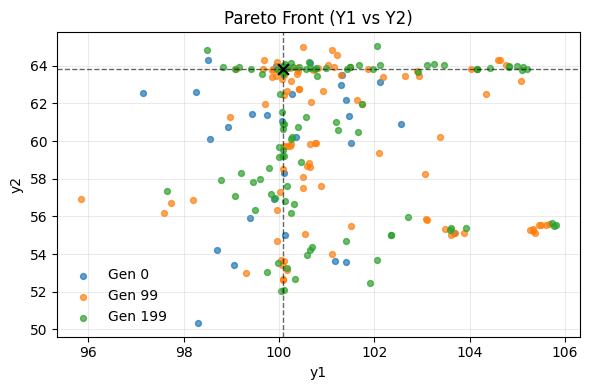

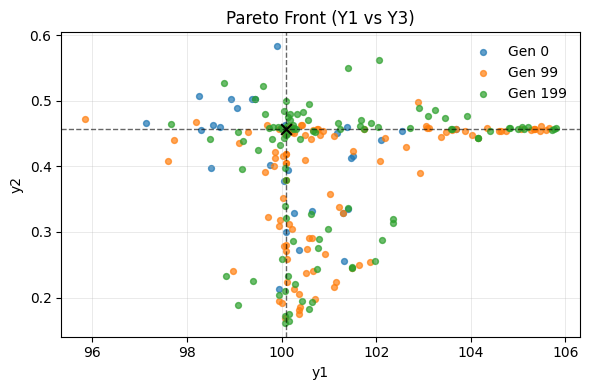

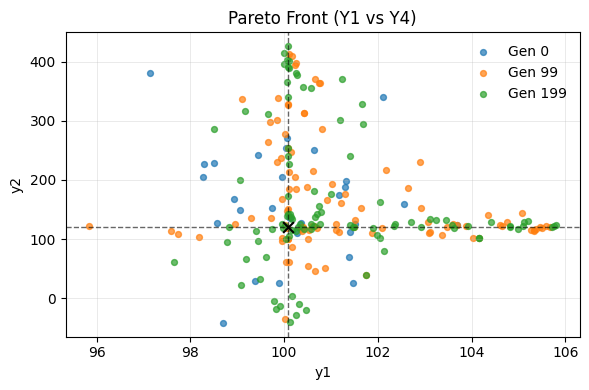

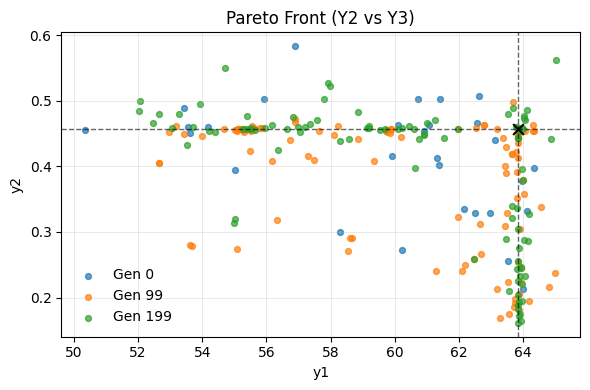

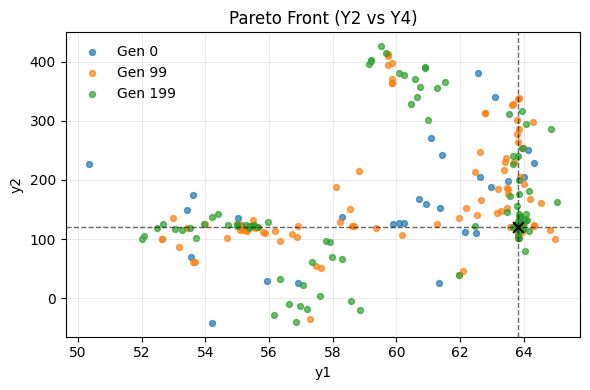

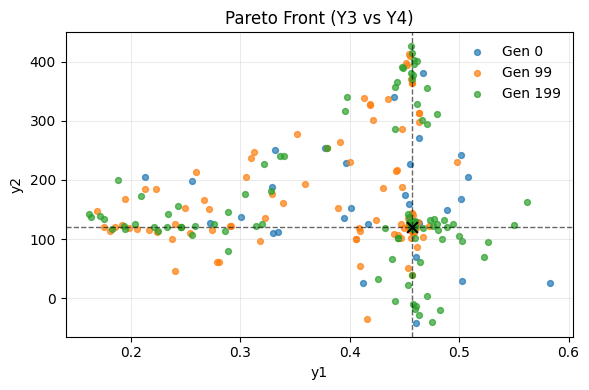

In [7]:
# Plot up to 10 target combinations
pairs = list(combinations(target_keys, 2))[:10]

for x_key, y_key in pairs:
    y1_gens = [[r.objectives[x_key] for r in gen] for gen in pareto_results]
    y2_gens = [[r.objectives[y_key] for r in gen] for gen in pareto_results]
    plot_pareto_front(
        y1_gens,
        y2_gens,
        target_x=objectives[x_key],
        target_y=objectives[y_key],
        title=f"Pareto Front ({x_key} vs {y_key})",
    )